# Data Exploration

In [1]:
# Suppress Possible Warnings : In some installations a warning due to pyg_lib path can arise: not relevant to our setting
import warnings
warnings.filterwarnings(
    "ignore",
    message=".*An issue occurred while importing 'pyg-lib'.*",
    category=UserWarning,
    module="torch_geometric.typing"
)
warnings.filterwarnings(
    "ignore",
    message=".*An issue occurred while importing 'torch-sparse'.*",
    category=UserWarning,
    module="torch_geometric.typing"
)

## Import packages

In [3]:
import torch
import numpy as np
import pandas as pd
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt

# Load SWaT dataset
Secure Water Treatment (SWaT) is a fully operational water treatment plant located in Singapore. The orignial data resolution is 1 second, but it was downsampled to 10 seconds for this workshop following the work of GDN.

It contains:
- 11 days continuous operations
- 7 days under normal operations
- 4 days were under attack scenarios
- 41 attacks in total

In [4]:
# print os gwd
import os
print(os.getcwd())

/Users/rtheiler/Workspaces/work/IMC-2025-GNN-Workshop/repository_public


In [5]:
df = pd.read_csv(f'run/datasets/swat/test.csv', index_col=0)
df.index = pd.to_datetime(df.index)

/var/folders/8w/nzvg2wnj1vg1xcs7s2d8097j3kqzdw/T/ipykernel_44126/942792365.py:2: UserWarning: Parsing dates in  %d/%m/%Y %I:%M:%S %p format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df.index = pd.to_datetime(df.index)


In [6]:
print(df.shape)
df.head()

(44991, 52)


,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,...,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,attack
Timestamp,,,,,,,,,,,,,,,,,,,,,
2015-12-28 10:00:00,0.943239,0.458333,1.0,1.0,0.0,0.62727,0.256121,0.104221,0.981817,1.0,...,1.0,0.0,0.946157,0.449782,0.943791,0.000073,0.0,0.0,0.0,0
2015-12-28 10:00:10,0.939214,0.457240,1.0,1.0,0.0,0.62727,0.251304,0.104221,0.981457,1.0,...,1.0,0.0,0.947378,0.449782,0.945860,0.000073,0.0,0.0,0.0,0
2015-12-28 10:00:20,0.893011,0.458378,1.0,1.0,0.0,0.62727,0.251304,0.104221,0.980684,1.0,...,1.0,0.0,0.947378,0.449782,0.945576,0.000073,0.0,0.0,0.0,0
2015-12-28 10:00:30,0.956481,0.459226,1.0,1.0,0.0,0.62727,0.253311,0.103356,0.980684,1.0,...,1.0,0.0,0.945718,0.449782,0.944075,0.000073,0.0,0.0,0.0,0
2015-12-28 10:00:40,0.917571,0.460565,1.0,1.0,0.0,0.62727,0.249297,0.103356,0.980684,1.0,...,1.0,0.0,0.945092,0.449782,0.942980,0.000073,0.0,0.0,0.0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 44991 entries, 2015-12-28 10:00:00 to 2016-01-02 14:59:41
Data columns (total 52 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   FIT101   44991 non-null  float64
 1   LIT101   44991 non-null  float64
 2   MV101    44991 non-null  float64
 3   P101     44991 non-null  float64
 4   P102     44991 non-null  float64
 5   AIT201   44991 non-null  float64
 6   AIT202   44991 non-null  float64
 7   AIT203   44991 non-null  float64
 8   FIT201   44991 non-null  float64
 9   MV201    44991 non-null  float64
 10  P201     44991 non-null  float64
 11  P202     44991 non-null  float64
 12  P203     44991 non-null  float64
 13  P204     44991 non-null  float64
 14  P205     44991 non-null  float64
 15  P206     44991 non-null  float64
 16  DPIT301  44991 non-null  float64
 17  FIT301   44991 non-null  float64
 18  LIT301   44991 non-null  float64
 19  MV301    44991 non-null  float64
 20  MV302    44991 

In [8]:
# Dataset Start Time and End Time
df_time_start = df.index[0]
df_time_end = df.index[-1]

# Visulization Strat Time and End Time
time_start =  pd.to_datetime('2015-12-29T00:00:00')
time_end =pd.to_datetime('2015-12-30T00:00:00')
time_len = int((time_end - time_start) / np.timedelta64(1, 's'))

def get_index(time):
    time = pd.to_datetime(time)
    return int((time - df_time_start) / np.timedelta64(10, 's'))

idx_start = get_index(time_start)
idx_end = get_index(time_end)
print(idx_start, idx_end)

5040 13680


# Visualization

Since the whole dataset time line is too long, here we only visulize 29 Dec 2015's data, you can easily change to what date you want to visulize by modifing start and end indexes.

## Set Anomaly Time Regions

We can get the information about attacks from SWaT dataset `SWaT.A1 & A2_Dec 2015/List_of_attacks_Final.pdf`. Here are attacks happened on 29 Dec 2015.

- `anomaly_feature` means this attack happened on what part of the system.
- `anomaly_time_start` and `anomaly_time_end` mark the duration of that attack.

Since the anomaly recording file is in bad format, so here I had to write down all attacks manually. You can still create a script to do this.

In [9]:
anomaly_feature = ['MV304', 'MV303', 'LIT301', 'MV303', 'AIT504', 'AIT504', 'MV101', 'LIT101', 'UV401', 'AIT502', 'P501']
anomaly_time_start = [np.array('2015-12-29T11:11:25', dtype=np.datetime64),
                      np.array('2015-12-29T11:35:40', dtype=np.datetime64),
                      np.array('2015-12-29T11:57:25', dtype=np.datetime64),
                      np.array('2015-12-29T14:38:12', dtype=np.datetime64),
                      np.array('2015-12-29T18:15:01', dtype=np.datetime64),
                      np.array('2015-12-29T18:15:43', dtype=np.datetime64),
                      np.array('2015-12-29T18:30:00', dtype=np.datetime64),
                      np.array('2015-12-29T18:30:00', dtype=np.datetime64),
                      np.array('2015-12-29T22:55:18', dtype=np.datetime64),
                      np.array('2015-12-29T22:55:18', dtype=np.datetime64),
                      np.array('2015-12-29T22:55:18', dtype=np.datetime64)
                      ]
anomaly_time_end = [np.array('2015-12-29T11:15:17', dtype=np.datetime64),
                    np.array('2015-12-29T11:42:50', dtype=np.datetime64),
                    np.array('2015-12-29T12:02:00', dtype=np.datetime64),
                    np.array('2015-12-29T14:50:08', dtype=np.datetime64),
                    np.array('2015-12-29T18:15:01', dtype=np.datetime64),
                    np.array('2015-12-29T18:22:17', dtype=np.datetime64),
                    np.array('2015-12-29T18:42:00', dtype=np.datetime64),
                    np.array('2015-12-29T18:42:00', dtype=np.datetime64),
                    np.array('2015-12-29T23:03:00', dtype=np.datetime64),
                    np.array('2015-12-29T23:03:00', dtype=np.datetime64),
                    np.array('2015-12-29T23:03:00', dtype=np.datetime64)
                    ]
assert len(anomaly_feature) == len(anomaly_time_start) and len(anomaly_feature) == len(anomaly_time_end)

In [10]:
ad_idx = anomaly_feature.index('MV101')
get_index(anomaly_time_start[ad_idx])

11700

In [11]:
# get each alarm's duration
anomaly_duration = []
for i in range(len(anomaly_feature)):
    start = (anomaly_time_start[i])
    end = (anomaly_time_end[i])
    anomaly_duration.append(end - start)
    print(f'{anomaly_feature[i]}: {start} - {end} = {end - start}')

MV304: 2015-12-29T11:11:25 - 2015-12-29T11:15:17 = 232 seconds
MV303: 2015-12-29T11:35:40 - 2015-12-29T11:42:50 = 430 seconds
LIT301: 2015-12-29T11:57:25 - 2015-12-29T12:02:00 = 275 seconds
MV303: 2015-12-29T14:38:12 - 2015-12-29T14:50:08 = 716 seconds
AIT504: 2015-12-29T18:15:01 - 2015-12-29T18:15:01 = 0 seconds
AIT504: 2015-12-29T18:15:43 - 2015-12-29T18:22:17 = 394 seconds
MV101: 2015-12-29T18:30:00 - 2015-12-29T18:42:00 = 720 seconds
LIT101: 2015-12-29T18:30:00 - 2015-12-29T18:42:00 = 720 seconds
UV401: 2015-12-29T22:55:18 - 2015-12-29T23:03:00 = 462 seconds
AIT502: 2015-12-29T22:55:18 - 2015-12-29T23:03:00 = 462 seconds
P501: 2015-12-29T22:55:18 - 2015-12-29T23:03:00 = 462 seconds


# Plot Signals with Anomaly Regions

### visualizing only signals with anomaly regions

In [12]:
def plot_attack_regions(selected_features, time_start=time_start, time_end=time_end):
    df_selected = df.loc[time_start:time_end]

    axes = df_selected.plot(y=selected_features, subplots=True, figsize=(12, 0.6*len(selected_features)), color='#2f83e4')

    for ad_feat, ad_start, ad_end in zip(anomaly_feature, anomaly_time_start, anomaly_time_end):
        mask = (df_selected.index >= ad_start) & (df_selected.index <= ad_end)
        if len(df_selected.loc[mask]) == 0 or ad_feat not in selected_features:
            continue
        df_selected.loc[mask, ad_feat].plot(ax=axes[selected_features.index(ad_feat)], color='tomato', linewidth=2)

    plt.show()

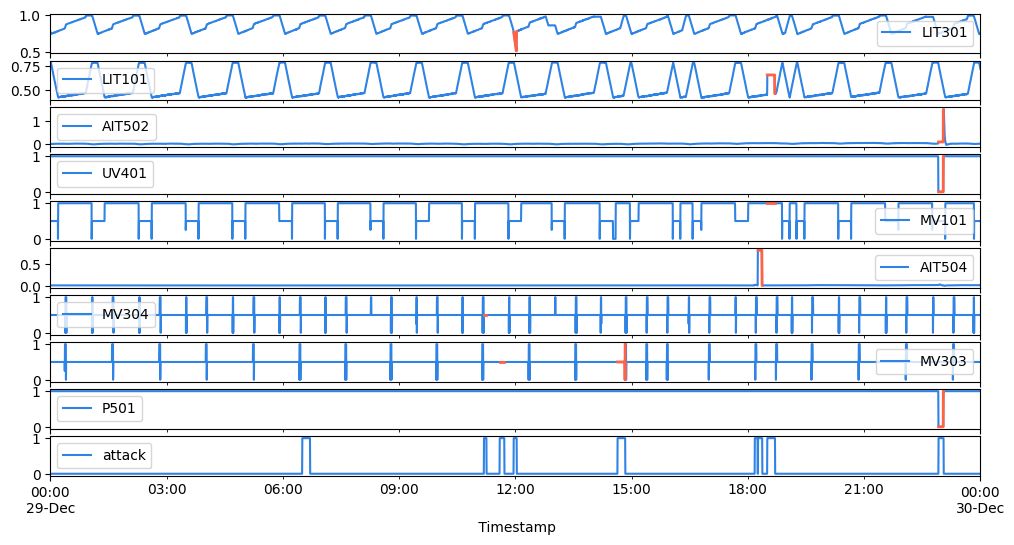

In [13]:
plot_attack_regions(selected_features=list(set(anomaly_feature))+['attack'])

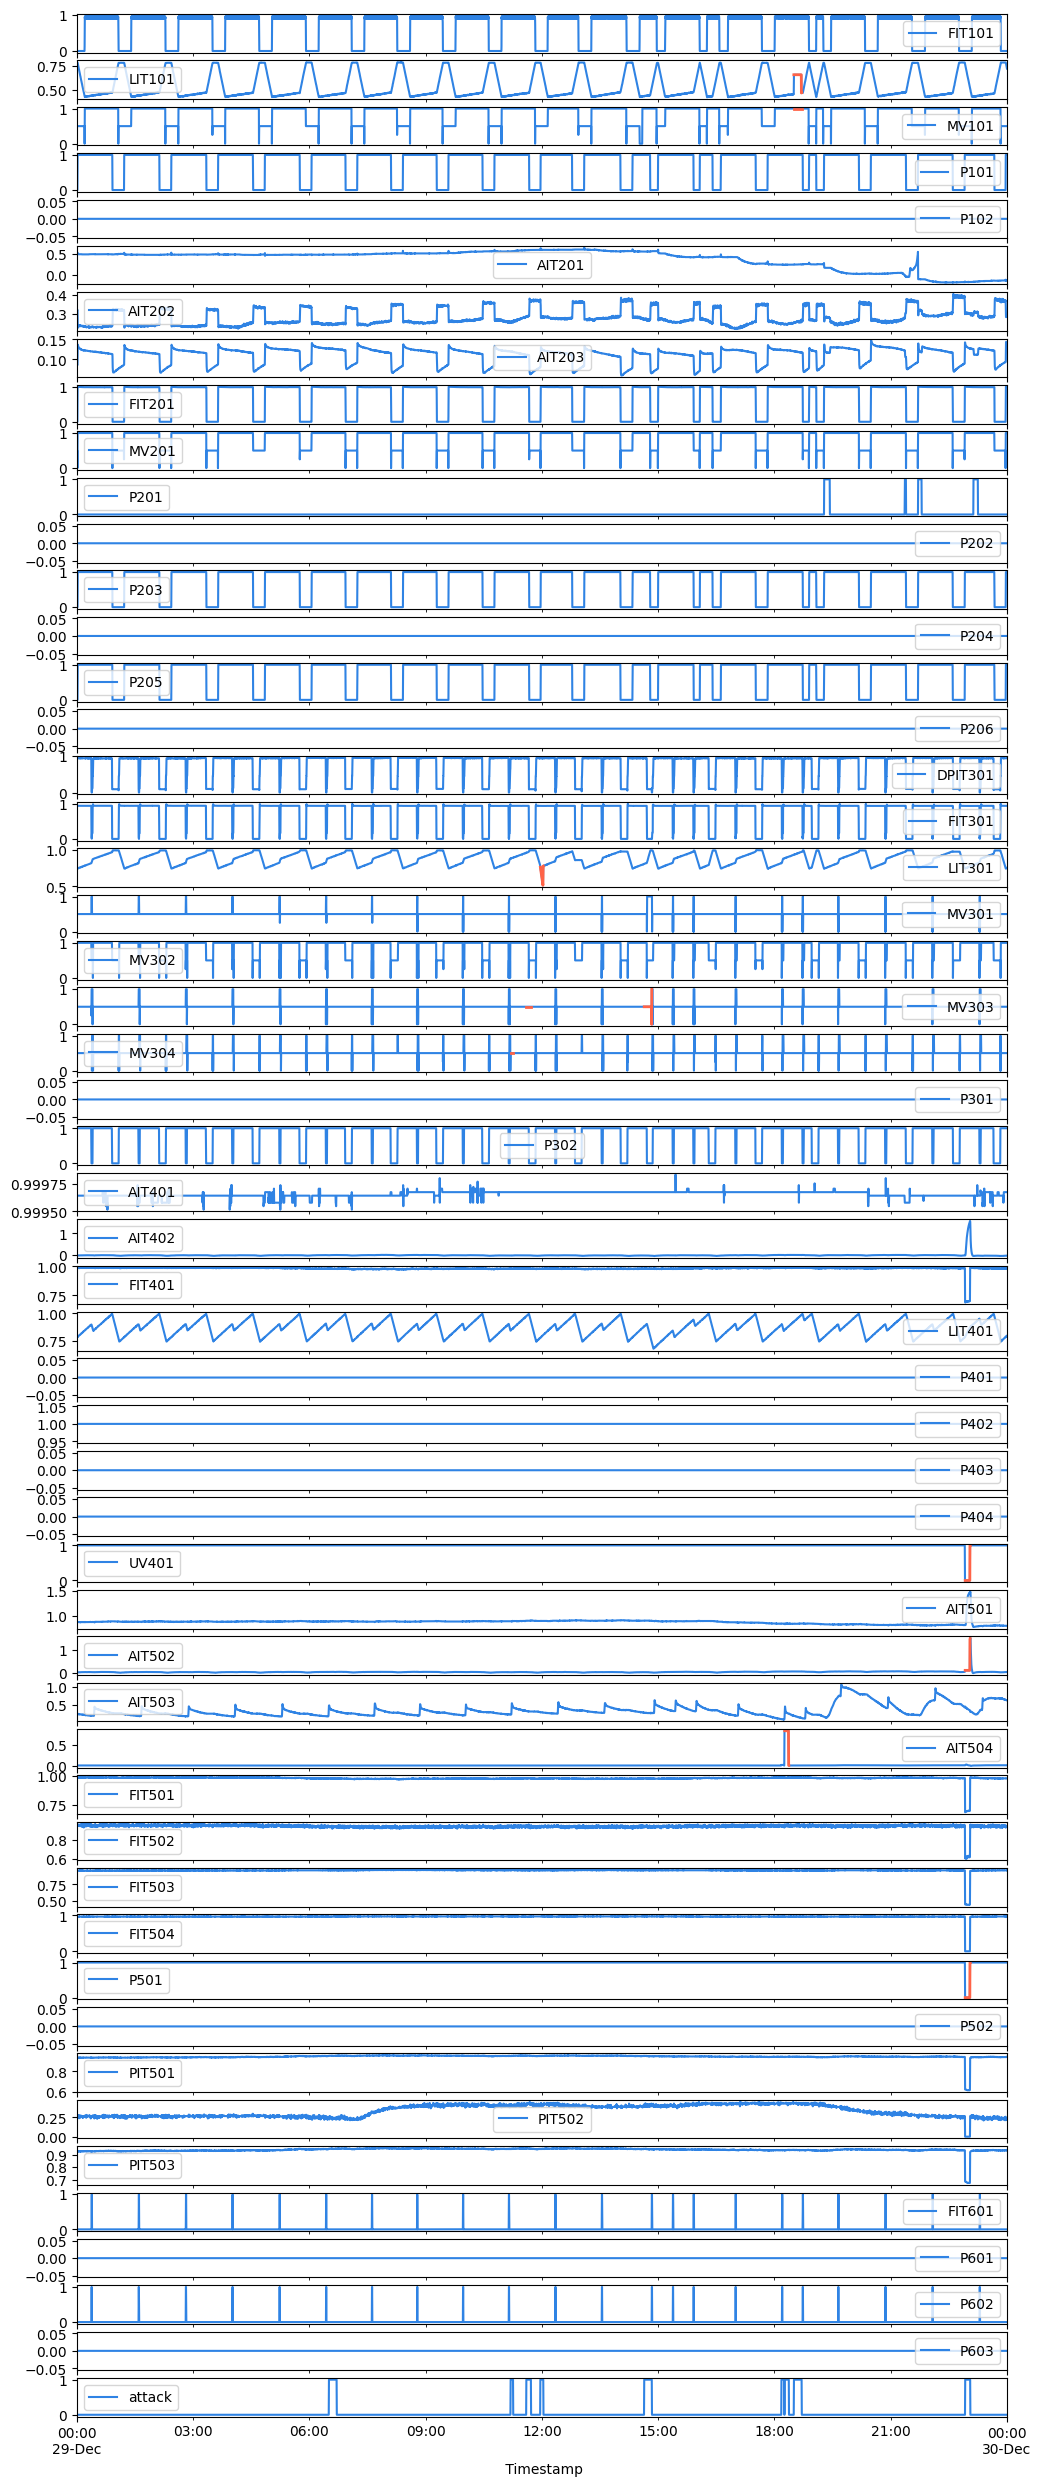

In [14]:
plot_attack_regions(selected_features=df.columns.tolist())

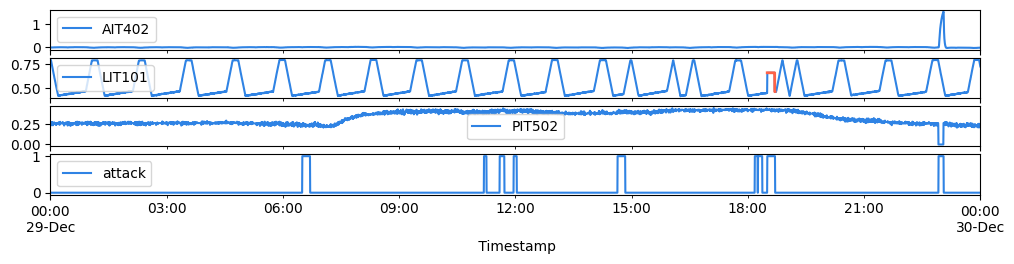

In [15]:
plot_attack_regions(selected_features=['AIT402', 'LIT101', 'PIT502', 'attack'])

### Can you spot which signals are under attack?

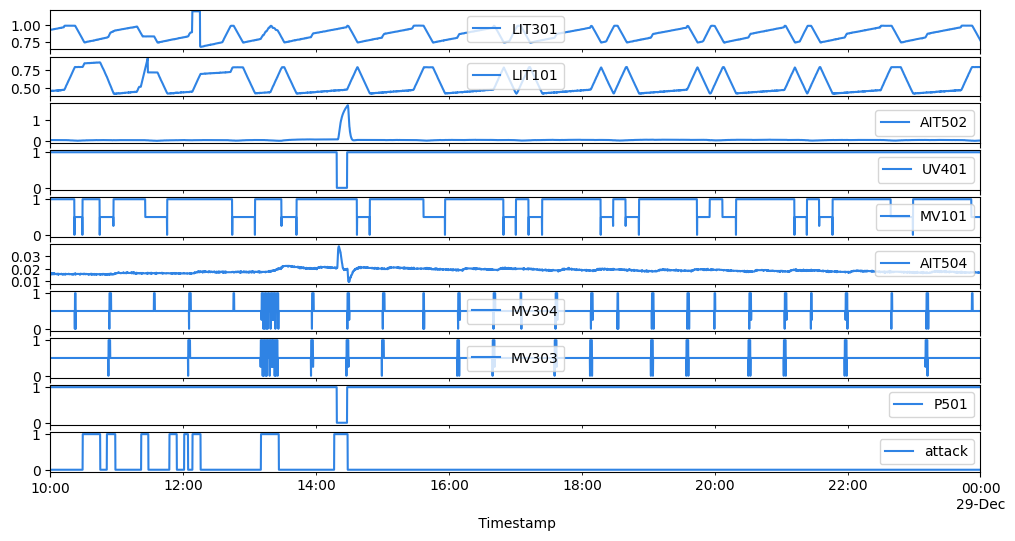

In [16]:
# Visulization Strat Time and End Time
time_start =  pd.to_datetime('2015-12-28T00:00:00')
time_end =pd.to_datetime('2015-12-29T00:00:00')
plot_attack_regions(selected_features=list(set(anomaly_feature))+['attack'], time_start=time_start, time_end=time_end)

# Analysis

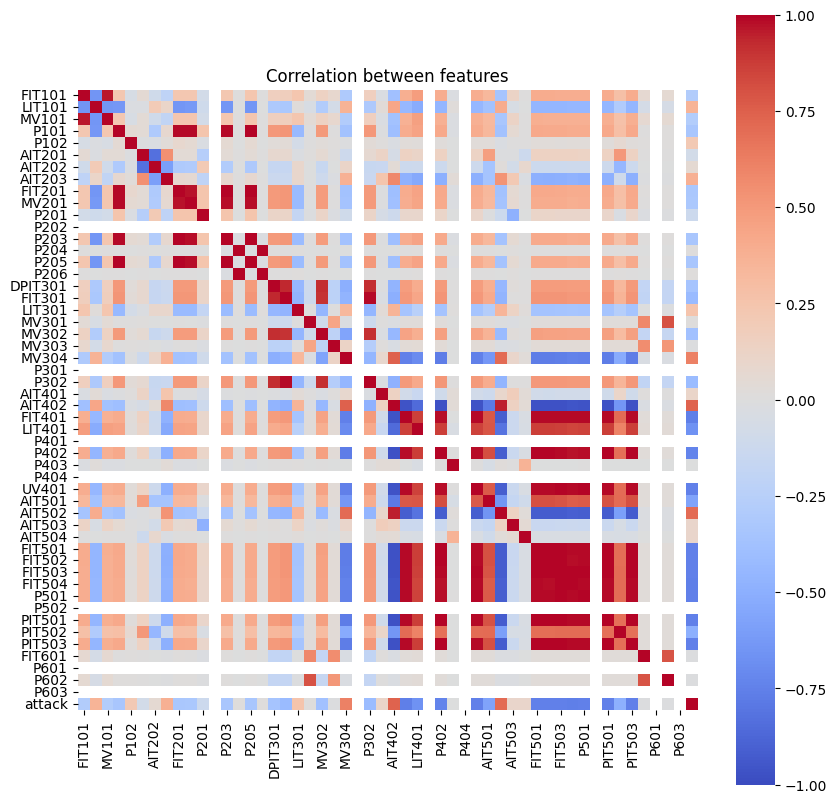

In [17]:
# draw correlation matrix
corr = df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr, vmax=1, vmin=-1, square=True, annot=False, cmap='coolwarm')
plt.title('Correlation between features')
plt.show()
